# Neural Network Regressor (MLP)

Feedforward MLP tuned with GridSearchCV on the cleaned FIFA dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor


In [2]:
data = pd.read_csv('../datasets/cleaned.csv')

target_col = 'Overall'
y = data[target_col]
mask = y.notna()
data = data[mask].copy()
y = y[mask]
drop_cols = [
    'ID', 'Name', 'Joined', 'Contract Valid Until',
    'Wage', 'Value', 'Release Clause',
    target_col
]
X = data.drop(columns=[c for c in drop_cols if c in data.columns])
categorical_cols = X.select_dtypes(include=['object']).columns
numeric_cols = X.columns.difference(categorical_cols)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ],
    remainder='drop'
)


In [3]:
mlp = MLPRegressor(
    random_state=42,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('mlp', mlp)
])

param_grid = {
    'mlp__hidden_layer_sizes': [(128, 64), (256, 128)],
    'mlp__activation': ['relu', 'tanh'],
    'mlp__alpha': [1e-4, 1e-3],
    'mlp__learning_rate_init': [0.001, 0.005],
    'mlp__batch_size': ['auto', 128]
}

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

grid = GridSearchCV(
    model,
    param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    n_jobs=-1,
    refit=True,
)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
best_params = grid.best_params_
best_cv_rmse = (-grid.best_score_) ** 0.5
print("Best MLP params:", best_params)
print(f"Best CV RMSE: {best_cv_rmse:.3f}")

y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
print(f"Train MSE:  {train_mse:.3f}")
print(f"Test MSE:   {test_mse:.3f}")
print(f"Test RMSE:  {np.sqrt(test_mse)}")
print(f"Test R2:    {r2_score(y_test, y_pred_test)}")


/Users/bunjiroyamada/Downloads/f1data/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/bunjiroyamada/Downloads/f1data/venv/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Best MLP params: {'mlp__activation': 'tanh', 'mlp__alpha': 0.001, 'mlp__batch_size': 128, 'mlp__hidden_layer_sizes': (256, 128), 'mlp__learning_rate_init': 0.001}
Best CV RMSE: 0.889
Train MSE:  0.126
Test MSE:   0.598
Test RMSE:  0.773406989582855
Test R2:    0.9871384851731669


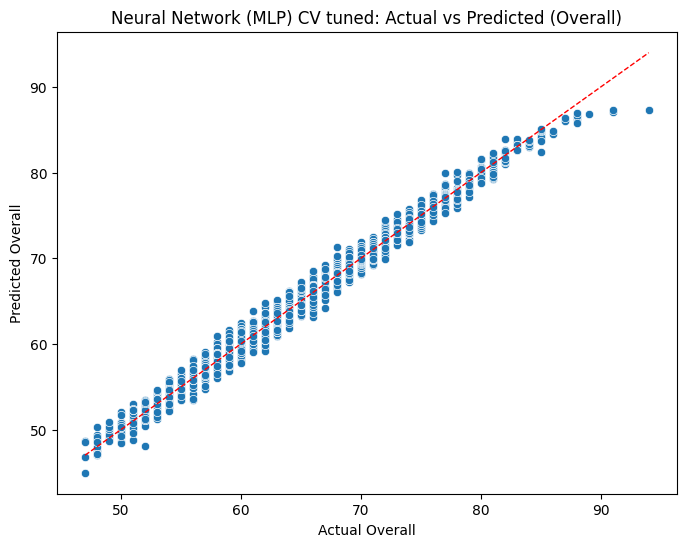

In [4]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel("Actual Overall")
plt.ylabel("Predicted Overall")
plt.title("Neural Network (MLP) CV tuned: Actual vs Predicted (Overall)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=1)
plt.show()
